## 1. Imports & Reading data

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
data_path = next((path for root in [Path.cwd(), *Path.cwd().parents]
                  for path in [root / 'data-analytics/data/raw/Risk_Assessments.csv',
                               root / 'data/raw/Risk_Assessments.csv']
                  if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Place Risk_Assessments.csv in data-analytics/data/raw/')

data_dir = data_path.parent
df = pd.read_csv(data_dir / 'Risk_Assessments.csv')
measurements = pd.read_csv(data_dir / 'Measurements.csv')
print(f"Risk Assessments shape: {df.shape}")
print(f"Measurements shape: {measurements.shape}")

Risk Assessments shape: (144, 8)
Measurements shape: (264, 8)


## 2. Understanding Data
- Dataframe shape
- head and tail
- dtypes
- describe

In [3]:
print(f'Shape: {df.shape}')

Shape: (144, 8)


In [4]:
#Displaying the first and last 10 rows of the DataFrame to get an overview of the data.
display(df.head(10))
display(df.tail(10))

  risk_assessment_id screening_id risk_level                risk_code assessment_source  requires_referral           assessed_at  rules_version
0           RSK-0001     SCR-0001        low       BLOOD_PRESSURE_LOW      rules_engine              False  2026-06-18T07:09:00Z  P80-RULES-1.0
1           RSK-0002     SCR-0002        low                  BMI_LOW      rules_engine              False  2026-06-18T07:13:00Z  P80-RULES-1.0
2           RSK-0003     SCR-0003        low              GLUCOSE_LOW      rules_engine              False  2026-06-18T07:17:00Z  P80-RULES-1.0
3           RSK-0004     SCR-0004        low          CHOLESTEROL_LOW      rules_engine              False  2026-06-18T07:21:00Z  P80-RULES-1.0
4           RSK-0005     SCR-0005        low               STRESS_LOW      rules_engine              False  2026-06-18T07:25:00Z  P80-RULES-1.0
5           RSK-0006     SCR-0006        low              FITNESS_LOW      rules_engine              False  2026-06-18T07:29:00Z  P80-RU

In [5]:
df.columns.tolist()

['risk_assessment_id', 'screening_id', 'risk_level', 'risk_code', 'assessment_source', 'requires_referral', 'assessed_at', 'rules_version']

In [6]:
df.dtypes

risk_assessment_id    object
screening_id          object
risk_level            object
risk_code             object
assessment_source     object
requires_referral       bool
assessed_at           object
rules_version         object
dtype: object

In [7]:
# Generating descriptive statistics for the DataFrame, including count, mean, std, min, 25%, 50%, 75%, and max for numerical columns, and unique, top, freq for categorical columns.
display(df.describe(include='all').T)

                   count unique                   top freq
risk_assessment_id   144    144              RSK-0001    1
screening_id         144    144              SCR-0001    1
risk_level           144      4              moderate   58
risk_code            144     20           FITNESS_LOW   15
assessment_source    144      1          rules_engine  144
requires_referral    144      2                 False  107
assessed_at          144    144  2026-06-18T07:09:00Z    1
rules_version        144      1         P80-RULES-1.0  144


## 3. Data Prep
- Dropping irrelevant columns and rows
- Identifying duplicated columns
- Renaming Columns
- Feature Creation


In [8]:
# Cleaning the DataFrame by removing duplicate rows and resetting the index to ensure a clean dataset for analysis.
# Duplicates can skew analysis and lead to incorrect conclusions, so it's important to handle them appropriately.
df = df.drop_duplicates().reset_index(drop=True)

# Cleaning column names by converting them to lowercase, replacing spaces and hyphens with underscores, and stripping any leading or trailing whitespace.
df.columns = [str(col).strip().lower().replace(' ', '_').replace('-', '_') for col in df.columns]

# Identifying and dropping unnecessary columns that may not contribute to the analysis, such as unnamed columns or those containing notes or remarks.
drop_cols = [col for col in df.columns if 'unnamed' in col.lower() or col.lower() in {'notes', 'remarks'}]
df = df.drop(columns=drop_cols)

# Count missing values in each row.
df['missing_count'] = df.isnull().sum(axis=1)
print(f'Cleaned shape: {df.shape}')
display(df.head())

Cleaned shape: (144, 9)
  risk_assessment_id screening_id risk_level           risk_code assessment_source  requires_referral           assessed_at  rules_version  missing_count
0           RSK-0001     SCR-0001        low  BLOOD_PRESSURE_LOW      rules_engine              False  2026-06-18T07:09:00Z  P80-RULES-1.0              0
1           RSK-0002     SCR-0002        low             BMI_LOW      rules_engine              False  2026-06-18T07:13:00Z  P80-RULES-1.0              0
2           RSK-0003     SCR-0003        low         GLUCOSE_LOW      rules_engine              False  2026-06-18T07:17:00Z  P80-RULES-1.0              0
3           RSK-0004     SCR-0004        low     CHOLESTEROL_LOW      rules_engine              False  2026-06-18T07:21:00Z  P80-RULES-1.0              0
4           RSK-0005     SCR-0005        low          STRESS_LOW      rules_engine              False  2026-06-18T07:25:00Z  P80-RULES-1.0              0


## 4. Review Summary Stats
- Understand the range, central tendency, and scale of numeric variables
- Identify skewness, low variability, or anomalies

In [9]:
# Identifying numeric columns in the DataFrame to generate descriptive statistics specifically for those columns, which can provide insights into the distribution and central tendency of the numerical data.
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if numeric_cols:
    display(df[numeric_cols].describe().T)
else:
    print("No numeric columns found in the DataFrame.")

               count  mean  std  min  25%  50%  75%  max
missing_count  144.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0




The sections above cover load, shape/dtype inspection, and basic profiling. The additions below fill the
gaps against the standard used for `Measurements.csv`: **grain integrity, missingness visualization,
categorical distribution, cross-field consistency, referral-rate diagnostics, and timestamp discipline** 
the checks that determine whether this risk table is safe to key into downstream models rather than just
descriptively summarized.

`Risk_Assessments.csv` stores risk in the categorical `risk_level` field
(low/moderate/high/critical), so the checks below use the fields that are present in the dataset.


## 5. Grain integrity

Confirming the primary key and the natural key explicitly, rather than inferring uniqueness from
`describe()` output.

In [10]:
# Primary key: risk_assessment_id should be unique
dupe_pk = df['risk_assessment_id'].duplicated().sum()
print(f"Duplicate risk_assessment_id values: {dupe_pk}")

# Natural key: this table appears to carry one risk assessment per screening.
# Confirm that explicitly rather than assuming it from row/column counts.
dupe_screening = df['screening_id'].duplicated().sum()
print(f"Duplicate screening_id values: {dupe_screening}")

if dupe_pk == 0 and dupe_screening == 0:
    print("\nGrain confirmed: one risk assessment per screening_id, keyed by risk_assessment_id.")
else:
    print("\nGrain violation found — investigate before this table is joined downstream.")

Duplicate risk_assessment_id values: 0
Duplicate screening_id values: 0

Grain confirmed: one risk assessment per screening_id, keyed by risk_assessment_id.


## 6. Missing data pattern (visual)

`describe(include='all')` showed `count == 144` for every column, i.e. no nulls, but a visual check is
worth doing on any table before trusting that, especially since this file loads from a raw CSV with no
schema enforcement at read time.

data-analytics/notebooks/eda/risk-assessments/Risk_Assessment_EDA.ipynb:cell-17:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


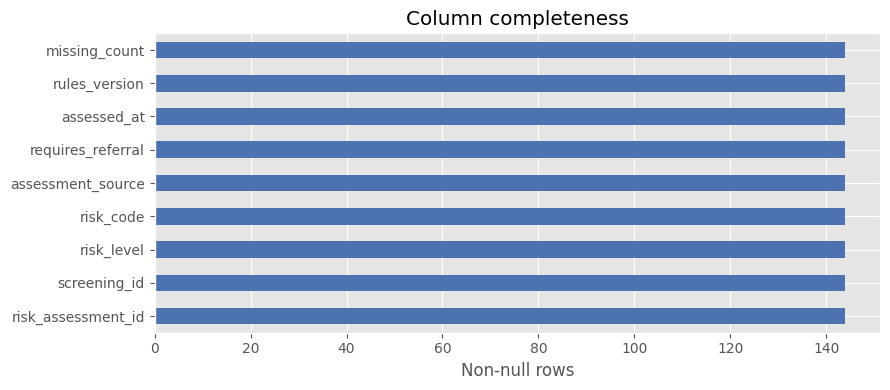

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
df.notna().sum().sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Non-null rows')
plt.title('Column completeness')
plt.tight_layout()
plt.show()

## 7. Categorical distribution diagnostics

The substance of this table is categorical (`risk_level`, `risk_code`, `requires_referral`,
`assessment_source`, `rules_version`), these deserve deliberate distribution checks, not just whatever
surfaces incidentally from `describe()`.

assessment_source unique values: ['rules_engine']
rules_version unique values: ['P80-RULES-1.0']


data-analytics/notebooks/eda/risk-assessments/Risk_Assessment_EDA.ipynb:cell-19:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


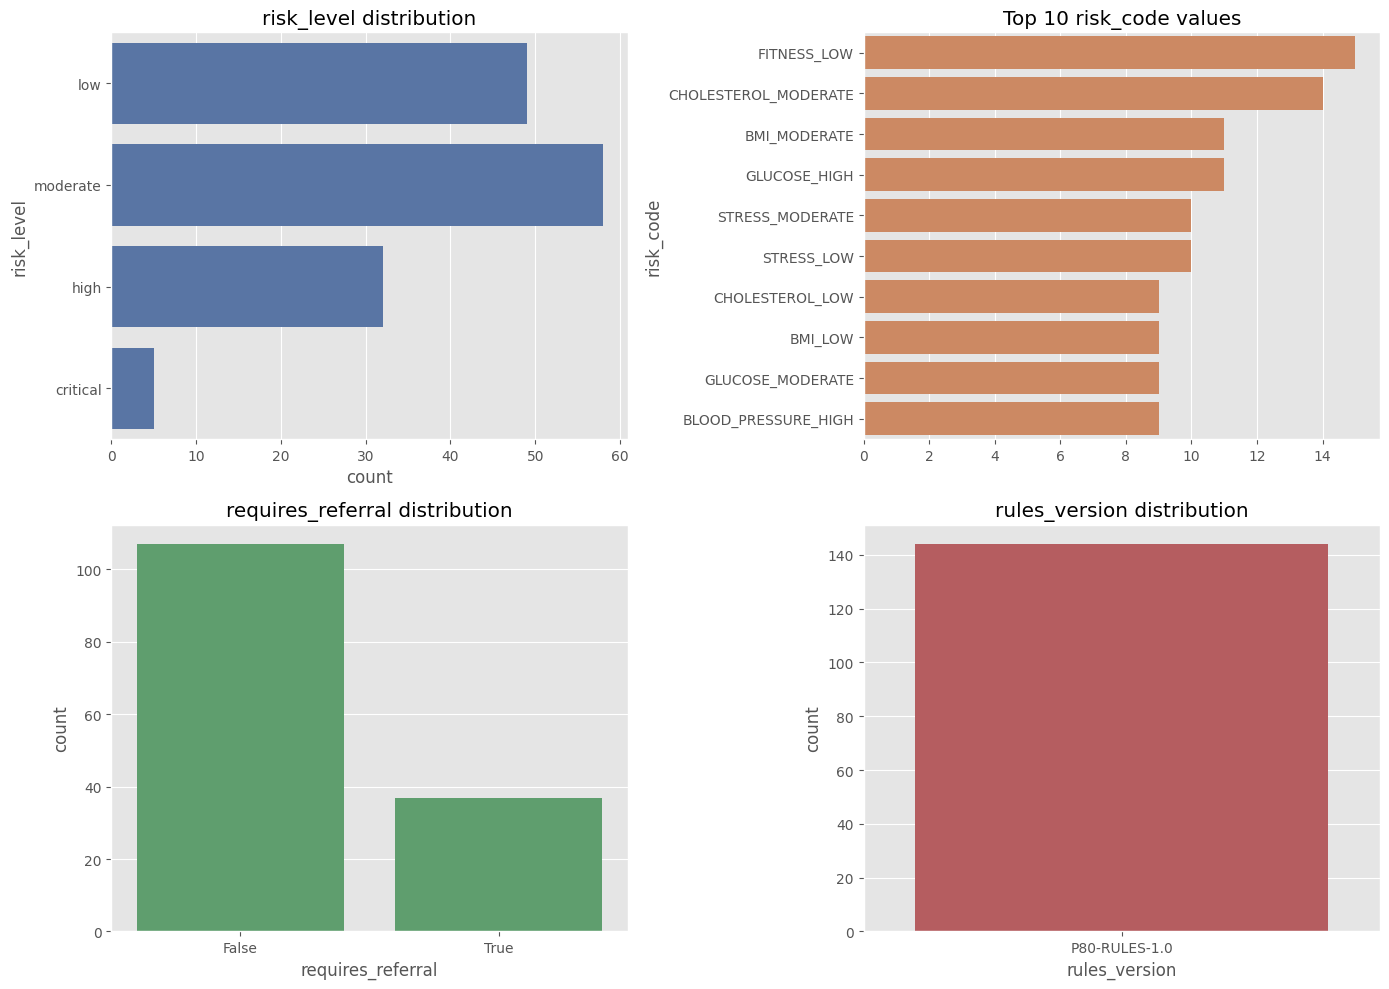

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# risk_level: the primary severity dimension
risk_level_order = ['low', 'moderate', 'high', 'critical']
sns.countplot(data=df, y='risk_level', order=risk_level_order, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('risk_level distribution')

# risk_code: many distinct values, so show only the most frequent
top_codes = df['risk_code'].value_counts().head(10)
sns.barplot(x=top_codes.values, y=top_codes.index, ax=axes[0, 1], color='#DD8452')
axes[0, 1].set_title('Top 10 risk_code values')

# requires_referral: binary flag
sns.countplot(data=df, x='requires_referral', ax=axes[1, 0], color='#55A868')
axes[1, 0].set_title('requires_referral distribution')

# rules_version / assessment_source: confirm these are as constant as describe() suggested
sns.countplot(data=df, x='rules_version', ax=axes[1, 1], color='#C44E52')
axes[1, 1].set_title('rules_version distribution')

plt.tight_layout()
plt.show()

print("assessment_source unique values:", df['assessment_source'].unique().tolist())
print("rules_version unique values:", df['rules_version'].unique().tolist())

## 8. Cross-field consistency: `risk_code` vs `risk_level`

Every `risk_code` encodes a severity suffix (`_LOW`, `_MODERATE`, `_HIGH`, `_CRITICAL`). That suffix should
always agree with `risk_level`; a mismatch would mean the rules engine and the stored risk level
disagree, which is exactly the kind of bug that should be caught before a risk indicator ships.

In [13]:
def extract_suffix(code):
    for level in ['LOW', 'MODERATE', 'HIGH', 'CRITICAL']:
        if code.endswith(level):
            return level.lower()
    return None

df['risk_code_suffix'] = df['risk_code'].apply(extract_suffix)

# Cross-tab: off-diagonal cells would indicate a mismatch between risk_code and risk_level
consistency = pd.crosstab(df['risk_level'], df['risk_code_suffix'])
display(consistency)

mismatches = df[df['risk_level'] != df['risk_code_suffix']]
print(f"\nRows where risk_level disagrees with the risk_code suffix: {len(mismatches)}")
if len(mismatches):
    display(mismatches[['risk_assessment_id', 'risk_code', 'risk_level', 'risk_code_suffix']])
else:
    print("None found — risk_code and risk_level are fully consistent in this extract.")

risk_code_suffix  critical  high  low  moderate
risk_level                                     
critical                 5     0    0         0
high                     0    32    0         0
low                      0     0   49         0
moderate                 0     0    0        58

Rows where risk_level disagrees with the risk_code suffix: 0
None found — risk_code and risk_level are fully consistent in this extract.


## 9. Referral rate by risk level

Sanity check on the rules engine's referral logic: referral rate should scale with severity, and it's
worth confirming there isn't a `high`/`critical` case slipping through without a referral flag.

            referral_rate  referral_count  total_count
risk_level                                            
low                   0.0               0           49
moderate              0.0               0           58
high                  1.0              32           32
critical              1.0               5            5
high/critical rows missing a referral flag: 0


data-analytics/notebooks/eda/risk-assessments/Risk_Assessment_EDA.ipynb:cell-23:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


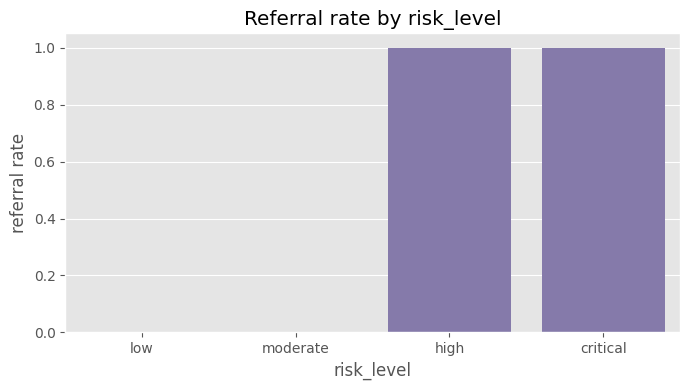

In [14]:
referral_by_level = df.groupby('risk_level')['requires_referral'].agg(['mean', 'sum', 'count'])
referral_by_level.columns = ['referral_rate', 'referral_count', 'total_count']
referral_by_level = referral_by_level.reindex(['low', 'moderate', 'high', 'critical'])
display(referral_by_level)

plt.figure(figsize=(7, 4))
sns.barplot(x=referral_by_level.index, y=referral_by_level['referral_rate'], color='#8172B2')
plt.ylim(0, 1.05)
plt.ylabel('referral rate')
plt.title('Referral rate by risk_level')
plt.tight_layout()
plt.show()

# Flag any high/critical case that did NOT get a referral flag
missed_referrals = df[(df['risk_level'].isin(['high', 'critical'])) & (~df['requires_referral'])]
print(f"high/critical rows missing a referral flag: {len(missed_referrals)}")
if len(missed_referrals):
    display(missed_referrals[['risk_assessment_id', 'risk_level', 'risk_code', 'requires_referral']])

## 10. Timestamp discipline

Same standard applied to `Measurements.csv`: confirm `assessed_at` parses cleanly and is consistently UTC
before it's used in any windowing or time-based logic.

In [15]:
df['assessed_at_parsed'] = pd.to_datetime(df['assessed_at'], utc=True, errors='coerce')
n_unparseable = df['assessed_at_parsed'].isna().sum()
print(f"Unparseable timestamps: {n_unparseable}")
print(f"Range: {df['assessed_at_parsed'].min()}  ->  {df['assessed_at_parsed'].max()}")

non_utc_suffix = (~df['assessed_at'].str.endswith('Z')).sum()
print(f"Timestamps not using explicit 'Z' (UTC) suffix: {non_utc_suffix}")

Unparseable timestamps: 0
Range: 2026-06-18 07:01:00+00:00  ->  2026-06-18 09:59:00+00:00
Timestamps not using explicit 'Z' (UTC) suffix: 0


## 11. Measurements relationship validation

Validate `Measurements.screening_id` against `Risk_Assessments.screening_id` in both directions. Measurements can contain several metric rows for one screening, while Risk Assessments should contain one row per screening.

In [16]:
risk_screening_ids = set(df['screening_id'].dropna())
measurement_screening_ids = set(measurements['screening_id'].dropna())

risk_without_measurements = risk_screening_ids - measurement_screening_ids
measurements_without_risk = measurement_screening_ids - risk_screening_ids
missing_risk_screening_ids = df['screening_id'].isna().sum()
missing_measurement_screening_ids = measurements['screening_id'].isna().sum()

measurement_risk_join = measurements.merge(
    df[['screening_id', 'risk_assessment_id']],
    on='screening_id',
    how='left',
    validate='many_to_one',
)

print(f"Confirmed risk assessment screening IDs: {len(risk_screening_ids)}")
print(f"Confirmed measurement screening IDs: {len(measurement_screening_ids)}")
print(f"Measurement rows joined to a risk assessment: {measurement_risk_join['risk_assessment_id'].notna().sum()} of {len(measurements)}")
print(f"Missing screening_id values in Risk Assessments: {missing_risk_screening_ids}")
print(f"Missing screening_id values in Measurements: {missing_measurement_screening_ids}")
print(f"Risk Assessments with no Measurements: {len(risk_without_measurements)}")
print(f"Measurement screening IDs with no Risk Assessment: {len(measurements_without_risk)}")

Confirmed risk assessment screening IDs: 144
Confirmed measurement screening IDs: 144
Measurement rows joined to a risk assessment: 264 of 264
Missing screening_id values in Risk Assessments: 0
Missing screening_id values in Measurements: 0
Risk Assessments with no Measurements: 0
Measurement screening IDs with no Risk Assessment: 0


## 12. Final relationship-validation summary

### Confirmed

- Risk Assessments has one row per `screening_id`.
- Measurements has many metric rows per `screening_id`.
- All 144 Risk Assessment screening IDs exist in Measurements.
- All 144 Measurement screening IDs exist in Risk Assessments.
- All 264 Measurement rows join to one Risk Assessment.

### Missing

- Missing `screening_id` values in Risk Assessments: 0.
- Missing `screening_id` values in Measurements: 0.

### Orphaned

- Risk Assessments without Measurements: 0.
- Measurement screening IDs without Risk Assessments: 0.

### Business rule requiring clarification

- The current data shows exactly one Risk Assessment for every screening. Confirm whether this is a required rule or only true for this sample.
- Confirm whether a screening may be reassessed later. If yes, the expected relationship could become one screening to many Risk Assessments.
- Confirm whether every screening must create a Risk Assessment, including screenings with only low-risk measurements.